In [85]:
import os
import re
import gc
import psutil

import numpy as np
from numpy.random import randint, normal, uniform
import pylab as pl
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

from joblib import Parallel, delayed
from functools import partial

from astropy import units as u

import healpy as hp
import camb

from ksw import Cosmology, Data
from ksw.radial_functional import radial_func

%matplotlib inline

In [86]:
def p_mem():
    pid = os.getpid()
    py = psutil.Process(pid)
    memory_info = py.memory_info()
    memory_use_in_bytes = memory_info.rss
    memory_use_in_gb = memory_use_in_bytes / (1024 ** 3)
    return f'{memory_use_in_gb:,.4f} GB'

# Data Generator

This code primamrly uses [KSW](https://github.com/AdriJD/ksw/tree/master/src), as a means to generate non-gaussian cmb maps. These get stored in a data file with the fnls, fullsky maps, and patches.

The fullsky maps are generated using the method discussed in [CMB lensing and primordial non-Gaussianity](https://arxiv.org/abs/0905.4732), where we find (eq. 6) 
$$
a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}{^{NG}}
$$
and generated the full sky map by passing these $a_{\ell m}$ into healpy.

Most of this code is to calculate the term (eq. 27)

$$
a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]
$$

and

$$
\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)
$$

$$
\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)
$$

$$
B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}
$$

where $\Delta_\phi$ is pridormial normalizatiopn, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions

---

## Settings

See: https://camb.readthedocs.io/en/latest/model.html

Some values are forced during init of ksw.Cosmology. 
For an example on how to modify these values after init: https://github.com/AdriJD/ksw/blob/fba3250cfe4c5145b5db12fa54bbc54bbcf5a56c/tests/python/test_cosmology.py#L65

In [87]:
cosmo_params = {
    'H0': 67.5,
    'r': 0,
    'As': 2.13e-09,
    'ns': 0.9624,
    'pivot_scalar': 0.05,
    'ombh2': 0.02233,
    'omch2': 0.1198,
    'mnu': 0.06,
    'tau': 0.0561,
    'TCMB': 2.7255,
    'max_l': 3000, # should be higher then lmax below, will get c_l_max > lmax error otherwise, for some reason
}

This lmax is the one that really gets used.
lmax >= 300 is enforced by the ksw code due to errors with CAMB. 
lmax needs to be somewhat smaller then max_l, if you get errors about c_ell change these.
You will get warning messages if lmax > 4\* nside.  

nside should be of type 2\*\*n

num_patches should be even.

patch_side_deg \* num_patches \<\= 180, patch_side_deg \<\= 45; or you will overlap patches 

r_max is given in Mpc, we preform r_res slices over this volume to do the integral. Values have been picked by guestimation, with r_res being set low to help test. Will want to raise this for better calculations.

KSW only supports polarization values of 'T', 'E', ['T', 'E'].

r_res % r_batch must be 0, this could be fixed but it was looking like that would be more trouble then its worth

In [88]:
lmax = 1000

fnl_range=(-1000, 1000)

nsims = 10
npatches = 10
batch_size = 100

nside=256
patch_side_deg = 10

r_min = 1                     # Mpc, min radius for the patch, >1e-6, but I've had issues below 1 with kernel crashes       
r_max = 14000                 # Mpc, max radius for the patch
r_res = 100                 # number of slices in the radius, memory usage is greatly impacted by this
r_batch = 50                 # number of slices to compute at once

# KSW only supports 'T' and 'E'
polarizations = ['T']
# polarizations = ['T', 'E']

# FWHM of gaussian beam, use astropy units to make thing easy here
beam_width = 1 * u.arcmin # type: ignore

# noise settings, for the noise covariance matrix (without beam) in uK^2.
noise_loc = 0.
noise_scale = 0.1
parallel = Parallel(-1, verbose=100)

In [89]:
npol = 1 if isinstance(polarizations, str) else len(polarizations)
pol = npol > 1
nell = lmax + 1

ls, ms = hp.Alm.getlm(lmax)

npol, pol, nell, ls.shape, ms.shape

(1, False, 1001, (501501,), (501501,))

In [90]:
radii = np.linspace(r_min, r_max, r_res)

# np.split didnt do what I wanted
def split_into_batches(data, batch_size):
    batches = []
    indices = []
    
    # number of complete batches
    num_batches = len(data) // batch_size
    
    for i in range(num_batches):
        batches.append(data[i*batch_size:(i+1)*batch_size])
        indices.append(np.arange(i*batch_size, (i+1)*batch_size))
    
    # if there are leftover elements
    if len(data) % batch_size != 0:
        batches.append(data[num_batches*batch_size:])
        indices.append(np.arange(num_batches*batch_size, len(data)))
        
    return np.ascontiguousarray(batches), np.ascontiguousarray(indices)

# will throw an error if radii % r_batch != 0
radii_s, radii_i = split_into_batches(radii, r_batch)

p_mem(), radii.shape, len(radii_s), len(radii_i)

('1.8006 GB', (100,), 2, 2)

In [91]:
noise_ell = normal(noise_loc, noise_scale, (3, nell) if pol else (nell))
beam_ell = hp.gauss_beam(beam_width.to_value(u.radian), lmax, pol)

p_mem(), noise_ell.shape, beam_ell.shape

('1.8006 GB', (1001,), (1001,))

## Simulate the patches

In [92]:
camb_params_obj = camb.set_params(**cosmo_params)
cosmo = Cosmology(camb_params_obj, verbose=True)

Updated CAMB param: DoLateRadTruncation from True to False.
Updated CAMB param: AccuracyBoost from 1.0 to 2.
Updated CAMB param: BessIntBoost from 1.0 to 30.
Updated CAMB param: KmaxBoost from 1.0 to 3.
Updated CAMB param: IntTolBoost from 1.0 to 4.
Updated CAMB param: TimeStepBoost from 1.0 to 4.
Updated CAMB param: SourcekAccuracyBoost from 1.0 to 5.
Updated CAMB param: BesselBoost from 1.0 to 5.
Updated CAMB param: IntkAccuracyBoost from 1.0 to 5.
Updated CAMB param: lSampleBoost from 1.0 to 2.
Updated CAMB param: lAccuracyBoost from 1.0 to 2.
Updated CAMB param: AccurateBB from False to True.


In [93]:
cosmo.compute_transfer(cosmo_params['max_l'], verbose=True)
cosmo.compute_c_ell()

In [94]:
data = Data(lmax, noise_ell, beam_ell, polarizations, cosmo)

In [95]:
alm = data.compute_alm_sim(lens_power=False)

In [96]:
c_ells = data.cosmology.c_ell['unlensed_scalar']['ells'] # type: ignore
tr_ell_k = data.cosmology.transfer['tr_ell_k']
ells = data.cosmology.transfer['ells']
ks = data.cosmology.transfer['k']

tr_ell_k.shape, ells.shape, ks.shape, c_ells.shape

((167, 32896, 2), (167,), (32896,), (3001,))

$$
a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]
$$

In [97]:
def get_alpha_l(tr_ell_k, ks, ells, radii):
    # radial func does f_ell^X(r) = (2/pi) int k^2 dk f(k) transfer^X_ell(k) j_ell(k r)
    f_k = np.ones((len(ks),1))
    return radial_func(f_k, tr_ell_k.copy(), ks, radii, ells).squeeze()

def get_beta_l(tr_ell_k, ks, ells, delta_phi, radii):
        # radial func does f_ell^X(r) = (2/pi) int k^2 dk f(k) transfer^X_ell(k) j_ell(k r)
        f_k = np.swapaxes([ks**-1 * delta_phi], 0, 1)
        return radial_func(f_k, tr_ell_k.copy(), ks, radii, ells).squeeze()

def interpolate_ells(func, ells_sparse, ls):
    return CubicSpline(ells_sparse, func, axis=1)(ls)

delta_phi = 2 * np.pi ** 2 * cosmo_params['As'] * (3 / 5)**2

def inner(p, bl_div_cl):
        Balm = hp.almxfl(alm[p], bl_div_cl)
        B = hp.alm2map(Balm, nside=nside, lmax=lmax, mmax=None, pol=pol, pixwin=False, fwhm=0, sigma=None)
        return hp.map2alm(B**2, lmax=lmax, mmax=None, pol=pol) 

def get_sum(dr, radii, alpha_ls, inner):
        return np.sum([dr * radii[i]**2 * hp.almxfl(inner[i], alpha_ls[i,:,p]) for i in range(len(radii)) for p in range(npol)], axis=0)

def get_alm_ngs(tr_ell_k, ells, c_ells, radii, p):
    alpha_ell = np.concatenate([get_alpha_l(tr_ell_k, ks, ells, radii)])
    alpha_l = np.concatenate([interpolate_ells(alpha_ell, ells, np.arange(lmax))])
    alpha_l = np.ascontiguousarray(alpha_l)

    beta_ell = np.concatenate([get_beta_l(tr_ell_k, ks, ells, delta_phi, radii)])
    div = beta_ell / c_ells[None, ells, None]
    bl_div_cl = np.concatenate(np.array([interpolate_ells(div, ells, np.arange(lmax))]))
    bl_div_cl = np.ascontiguousarray(bl_div_cl)

    _inner = np.array([inner(p, bl_div_cl[i,:,p]) for i in range(len(radii))])
    _inner = np.ascontiguousarray(_inner)
    
    dr = radii[1] - radii[0]
    alm_ng = np.array(get_sum(dr, radii, alpha_l, _inner)) # type: ignore
    return np.ascontiguousarray(alm_ng)

In [98]:
def cutSqPatches(fullsky_map, img_size, side_deg, num_patches):
    Tmap_datat = np.zeros((num_patches//2, int(img_size), int(img_size)))
    Tmap_datab = np.zeros((num_patches//2, int(img_size), int(img_size)))

    for counter in range(num_patches//2):
        Tmap_datat[counter] = np.ma.getdata(hp.cartview(fullsky_map, fig=0, xsize=img_size, ysize=img_size, rot=[0, 0], lonra=[side_deg*counter, side_deg*(counter+1)], latra=[0, side_deg],
                                                        title="CartView", unit="mK", format="%.2g", return_projected_map=True))
        Tmap_datab[counter] = np.ma.getdata(hp.cartview(fullsky_map, fig=1, xsize=img_size, ysize=img_size, rot=[0, 0], lonra=[side_deg*counter, side_deg*(counter+1)], latra=[-side_deg, 0],
                                                        title="CartView", unit="mK", format="%.2g", return_projected_map=True))
    
    return np.concatenate((Tmap_datat, Tmap_datab))

In [99]:
def get_sim_run():
    for sim in range(nsims):
        for p in range(npol):
            for radiis in radii_s:
                yield sim, p, radiis

def run_sim(tr_ell_k, ells, c_ells, nside, npatches, patch_side_deg, lmax, pol, alm, p, fnl, radiis):
    alm_ng = get_alm_ngs(tr_ell_k, ells, c_ells, radiis, p)

    alm_prime = alm + fnl * alm_ng
    alm_prime = np.ascontiguousarray(alm_prime.squeeze())

    maps  = hp.alm2map(alm_prime, nside, lmax=lmax, mmax=None, pol=pol, pixwin=False, fwhm=0, sigma=None)
    patches = cutSqPatches(maps, nside, patch_side_deg, npatches)
    
    return maps, patches


In [100]:
fnls = uniform(fnl_range[0], fnl_range[1], nsims).astype(np.float32)

In [110]:

pl.ioff()
sim_data = parallel(
    delayed(run_sim)(tr_ell_k, ells, c_ells, nside, npatches, patch_side_deg, lmax, pol, alm[p], p, fnls[sim], radiis) 
    for sim, p, radiis in get_sim_run()
)
pl.close('all')
pl.ion()

maps = np.array([i[0] for i in sim_data])
patches = np.concatenate(np.array([i[1] for i in sim_data]))

len(data), maps.shape, patches.shape

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done   2 out of  20 | elapsed:  1.6min remaining: 14.2min
[Parallel(n_jobs=-1)]: Done   3 out of  20 | elapsed:  1.6min remaining:  9.0min
[Parallel(n_jobs=-1)]: Done   4 out of  20 | elapsed:  1.6min remaining:  6.3min
[Parallel(n_jobs=-1)]: Done   5 out of  20 | elapsed:  1.6min remaining:  4.9min
[Parallel(n_jobs=-1)]: Done   6 out of  20 | elapsed:  1.6min remaining:  3.8min
[Parallel(n_jobs=-1)]: Done   7 out of  20 | elapsed:  1.6min remaining:  3.1min
[Parallel(n_jobs=-1)]: Done   8 out of  20 | elapsed:  1.6min remaining:  2.5min
[Parallel(n_jobs=-1)]: Done   9 out of  20 | elapsed:  1.6min remaining:  2.0min
[Parallel(n_jobs=-1)]: Done  10 out of  20 | elapsed:  1.6min remaining:  1.6min
[Parallel(n_jobs=-1)]: Done  11 out of  20 | elapsed:  1.7min remaining:  1.4min
[Parallel(n_jobs=-1)]: Done  12 out of  20 | elapse

(20, (20, 786432), (200, 256, 256))

Traceback (most recent call last):
  File "/users/stevensonb/.conda/envs/mlpng/lib/python3.11/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 278, in main
    registry[rtype][name] -= 1
    ~~~~~~~~~~~~~~~^^^^^^
KeyError: '/dev/shm/joblib_memmapping_folder_8113_1ac1f7bbb3d045ed92033fa156254217_888846a8e67f4ccb9d2fbd1dae47dee8/8113-46920301171664-0589173c3dae4dd0b6bf25a0cf1f13d7.pkl'
Traceback (most recent call last):
  File "/users/stevensonb/.conda/envs/mlpng/lib/python3.11/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 278, in main
    registry[rtype][name] -= 1
    ~~~~~~~~~~~~~~~^^^^^^
KeyError: '/dev/shm/joblib_memmapping_folder_8113_1ac1f7bbb3d045ed92033fa156254217_888846a8e67f4ccb9d2fbd1dae47dee8/8113-46920301171664-0589173c3dae4dd0b6bf25a0cf1f13d7.pkl'
Traceback (most recent call last):
  File "/users/stevensonb/.conda/envs/mlpng/lib/python3.11/site-packages/joblib/externals/loky/backend/resource_tracker.py", line 278, in main
    

---

# Tests

Randomized visual test, change 4 to the number of test plots you want

In [103]:
random_indices = [(0, randint(nsims), randint(npatches)) for _ in range(4)]

random_indices

[(0, 9, 7), (0, 2, 9), (0, 0, 7), (0, 9, 3)]

TypeError: Invalid shape (256,) for image data

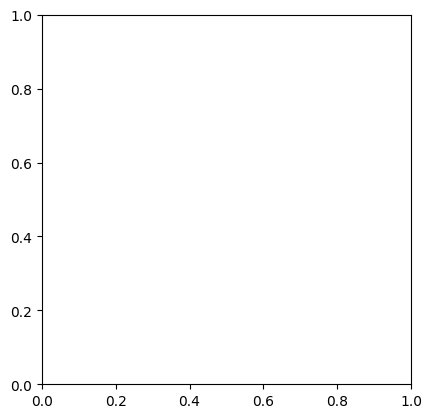

In [109]:
for pol, s, p in random_indices:
    plt.figure()
    plt.imshow(patches[s, p])
    plt.title(f"patch {s*npatches + p} [fnl={fnls[s]}]")
    plt.show()

In [ ]:
for pol, s, p in random_indices:
    cl = hp.anafast(maps[pol, s], lmax=lmax)
    ell = np.arange(len(cl))
    plt.figure()
    plt.plot(ell, ell * (ell + 1) * cl)
    plt.title(f"sim {s} [fnl={fnls[s]}]")
    plt.show()

---

# Save

We will save the data below. Name is set by settings so it can be loaded easy by the model trainer.

Data output is
```
{
    'fnls': array((nsims)),
    'patches': array((npol, nsims, npatchs, nside, nside)),
    'maps': array((npol, nsims, 12*nside**2))
}
```
maps are the full healpy maps. 

The order of everything is set by nsims, with fnls[i] being used to generate the corresponding maps and patches.
Make sure you preserve this ordering.

We may want to optimize this with TFDatasets if we find GPU is idle a lot, which would indiciate data bound due to transfer.

---

In [ ]:
base_name = f'{nside}_{nsims}x{npatches}_fnl{fnl_range[0]}-{fnl_range[1]}-r{r_res}-p{polarizations}'
data_dir = f'data/ksw/'
filename = f'{base_name}.npy'

data_dir, filename

In [ ]:
if not os.path.exists(data_dir): 
    os.makedirs(data_dir)
    print(f'Created directory {data_dir}')
else:
    print(f'Reusing directory {data_dir}')
    # pattern = re.compile(f"{base_name}_\d+-\d+\.npy")
    pattern = re.compile(f"{base_name}.npy")
    for file in os.listdir(data_dir):
        if pattern.match(file):
            file_path = os.path.join(data_dir, file)
            os.remove(file_path)
            print(f"Deleted existing data file: {file_path}")

In [ ]:
print(f"Saving to {dir}/{filename}...", end=" ")

data = {
    'fnls':fnls, 
    'patches':patches, 
    'maps': maps
}

with open(f"{data_dir}/{filename}", "xb") as f:
    np.save(f, data) # type: ignore

print("Done!")

# Goodbye